# Crowdmark Student Grades Project

This notebook contains all the steps I took to load, process, visualize, and analyze student grades from a CSV file. 
It includes both my code and documentation notes.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Access The CSV

Take the titles from the first line of the CSV and parse each student line.

In [3]:
with open("Crowdmark.csv", "r") as f:
    Titles = f.readline().strip("\n").split()
    ClassInfo = []
    for studentline in f.readlines():
        ClassInfo.append(studentline.strip("\n").split())

# Dict V.1

Split each line into first name, last name, and an array of grades.

In [4]:
Dict = {
    "FirstNames":[x[0] for x in ClassInfo],
    "LastNames":[x[1] for x in ClassInfo],
    "Grades":[[int(g) for g in x[2:]] for x in ClassInfo]
    }

# Place all info into a pandas DataFrame

Each column is named based on the dictionary keys.

In [5]:
Dataframe = pd.DataFrame(Dict)

Notes on pd.DataFrame usage
---
First use of AI, I had this:

Dataframe = pd.DataFrame(Dict)

and I attempted to use columns =
to give names to each column based
off of whatever the name was in the csv file:

Dataframe = pd.DataFrame(Dict, columns=[x for x in Titles])

turns out columns= takes from the
dictionary names and organises each
column position, if I wanted column
to hold a custom title i would have
to do:

Dict = {f"Titles[0]"":[x[0] for x in ClassInfo], f"Titles[1]":[x[1] for x in ClassInfo], f"Titles[2]":[x[2:] for x in ClassInfo]}

I don't really need that so I'll keep it as a string



---
# Access Grades V.1
### Access the grade array from the pandas DataFrame

In [6]:
Grades = Dataframe.get("Grades")

### notes on Grades V.1

found through random testing and looking
through possibilities, .get() gives you all
of a single column, you can access each row
by asking for an index


---
# Access Grades V.2

In [6]:
NumOfAssignments = max(len(x) for x in Dict["Grades"])
GradesMatrix = np.array([x + [np.nan] * (NumOfAssignments - len(x)) for x in Dict["Grades"]])


### Notes on Grades V.2

Watched: "Learn NumPy in 1 hour!" by Bro Code on YouTube.

While learning NumPy, I realized
that storing grade data in arrays
makes accessing and manipulating
the data much easier. Converting
the grades into a NumPy matrix
allows efficient calculations for
statistics such as student averages,
assignment averages, class performance,
and identifying top scores.

This is how GradesMatrix was built

For each student's grade array, extend it with np.nan values
so that its length matches the total number of assignments.

Example:
x = [1,2,3]

total assignments = 5
len(x) = 3 → 2 assignments missing

row becomes:
[1,2,3] + [nan, nan] = [1,2,3,nan,nan]

---
# Graphing V.1


In [ ]:
# Graphing V.1 ###########################################################################

for i in range(len(Grades)):
   x = np.array([[x+1 for x in range(len(Grades[i]))]])
   y = [int(g) for g in Grades[i]]

   plt.plot(x, y, marker = "o", label=f"{Dataframe.get('FirstNames')[i]}")

plt.show()

plt.legend(loc="upper left")

### Notes on Graphing V.1

Second use of AI, wanted to add the names of the students
after successfully printing all the charts onto one graph,
found out to do so all I had to do was add label= into the plotting
and add .legend() with a location

---
# Graphing V.2

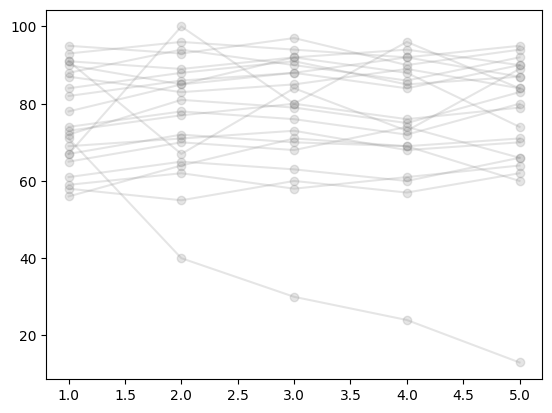

In [7]:
StudentLines = []

for studentgrades in GradesMatrix:
    x = plt.plot([x+1 for x in range(NumOfAssignments)], studentgrades, marker= 'o', color = "grey", alpha = 0.2)
    StudentLines.append(x)

### Notes on Graphing V.2


Watched "Learn NumPy in 1 hour!" by Bro Code on YouTube.

same senario as listed in "Grades V.2", and thanks to those
changes I was able to optimise the graphing loop, also added
a list to store each students line for future graph transformations

---
# Graphing V.3


In [ ]:
fig, ax = plt.subplots()
StudentLines = []

for studentgrades in GradesMatrix:
    line, = ax.plot([x+1 for x in range(NumOfAssignments)], studentgrades, marker= 'o', color = "grey", alpha = 0.2)
    StudentLines.append(line)

### Notes on Graphing V.3


---
# Useful Stats V.1

In [8]:
Averages = []
for g in Grades:
    totalprecentage = 0
    assignmentcount = 0

    for t in g:
        assignmentcount += 1
        totalprecentage += int(t)

    Averages.append(totalprecentage/assignmentcount)


'''Had to search up how to add a column, .loc does that'''

Averages = Dataframe.loc[:, 'Averages']

for i in range(len(Averages)):
    x = np.array([(i+1) for i in range(len(Averages))])
    y = np.array([Averages[i]])
    plt.plot(x, y, label=f"{Dataframe.get('FirstNames')[i]}'s Average")


NameError: name 'Grades' is not defined

### Notes on Useful Stats V.1

My idea for this is first learn how to update the graph based on what infos given
so if I'm looking for a certain student, I type in their name or index location
and a graph for them shows

Then, I want to be able to have all the graphs show, but different opacities
say I want Jane's info, the opacity for everyone else is lower, we only see jane's visibally

---
# Useful Stats V.2


In [9]:
StudentAverages = np.nanmean(GradesMatrix, axis=1) # each student's average

AveragePerAssignment =np.nanmean(GradesMatrix, axis=0) # class average on any assignment

ClassAverage = np.nanmean(GradesMatrix) # total class's average

TopStudent = np.argmax(StudentAverages) # find student index by highest average

### Notes on Useful Stats V.2

Watched "Learn NumPy in 1 hour!" by Bro Code on YouTube.
Same point stated in Grades V.2

---
# Useful Stats V.3

In [ ]:
StudentAverages = np.nanmean(GradesMatrix, axis=1) # each student's average

AveragePerAssignment =np.nanmean(GradesMatrix, axis=0) # class average on any assignment

ClassAverage = np.nanmean(GradesMatrix) # total class's average

TopStudent = np.argmax(StudentAverages) # find student index by highest average

FullNames = Dataframe["FirstNames"] + " " + Dataframe["LastNames"]

SortedIndices = np.argsort(-StudentAverages)

Ranks = np.empty_like(SortedIndices)

Ranks[SortedIndices] = np.arange(1, len(StudentAverages)+1)


### Notes on Useful Stats V.3
More complete Stats:

- `StudentAverages` collects the mean of each row in the Grades Matrix and sorts it all into a vector

- `AveragePerAssignment` collects the mean of each column in the Grades Matrix, essentially finding the Average grade per assignment and sorts it into a vector

- `ClassAverage` takes all the values from the grade matrix, each and every index it taken and an average is computed, holding the average of the entire class

- `TopStudent` looks through all the indexes of student averages and locates the index with the highest recorded number, which is the highest average on all assignments

- `FullNames` combines every first and last name together

- `SortedIndices` takes every index of StudentAverages, negates all of them, and organises them from smallest to biggest, the largest negatives(highest averages) will be at the front, what is created is an array of indexes, SortedIndices[0] = the index number of the student with the highest average

- Ranks creates an empty array the same shape as SortedIndices, with 0 initialized values

- `Ranks[SortedIndices]` : each index of Ranks gets replaced with the position of the student it belongs to (SortedIndices[0] =3, Ranks[3] = 1, the 3rd index in the dataframe is ranked the top student of the class)

---
# Chart Design Stats V.1

In [ ]:
plt.title("Student Grades Chart", family = "arial", fontsize = 20)
plt.ylabel("Precentage")
plt.xlabel("Assignment")
plt.ylim(0,100)
plt.yticks([x * 5 for x in range(21)])
plt.xticks([x+1 for x in range(NumOfAssignments)])
plt.grid()
plt.ion()

plt.show()

### Notes on Chart Design Stats V.1

Previously had no clead way to display the data gathered, now it's all presentable on a chart usint matplotlib

`plt.ion()` allows plots to update without blocking the script.

---
# Chart Design V.2

In [ ]:
ax.set_title("Student Grades Chart", family="arial", fontsize = 20)
ax.set_ylabel("Precentage")
ax.set_xlabel("Assignment")
ax.set_ylim(0,100)
ax.set_yticks([x * 5 for x in range(21)])

ax.grid()
plt.ion()
plt.show()

### Notes on Chart Design V.2

---
# Searching V.1


In [ ]:
def GetStudentIndex(name):
    First, Last = name.split(" ")
    mask = (Dataframe["FirstNames"] == First) & (Dataframe["LastNames"] == Last)
    if mask.any():
        index = np.where(mask)[0][0]
        return index
    else:
        print("Student not found")        
    
def AllToGray():
    for line in StudentLines:
        l = line[0] #line 2d object
        l.set_color('grey')
        l.set_alpha(0.2)
        l.set_linewidth(1)
    plt.draw()


def HighlightSelectStudent(index):
    line = StudentLines[index][0]      # get the Line2D object
    line.set_color('blue')             
    line.set_alpha(1)                  
    line.set_linewidth(2)              
    plt.draw()                         

while True:
    print("COMMANDS")
    print("S: SELECT SINGLE STUDENT")
    print("C: CLEAR")
    UserInput =input("INPUT: ").upper()
    if UserInput =="S":
        x = input("Select a student(first and last name(e.g. Jane Doe)): ")
        index = GetStudentIndex(x)
        HighlightSelectStudent(index)
    elif UserInput =="C":
        AllToGray()

### notes on Searching V.1

Adding in the first searchbar

- `GetStudentIndex` Takes a full name and checks if the student exists in the class, if they do the student's index is returned

- `mask` Using Numpy, we are checking each name for a match, if both cases are true, we found a match, the student exists, faster than for loops, shorter too

- `mask.any()` returns true if at least ONE index is true

-  `index` mask is now an array [T,F,F,F] we want the only True, np.where returns a tuple: (array([2]),) we want the first element of the tuple: array([2]) and the first index of the array: 2, that's why we have [0][0]

- `AllToGray` Resets all the lines on the chart

- `HighlightSelectStudent` Takes an index, locates the student's line information from `StudentLines` and edits line information, `plt.draw()` then redraws the chart

---
# Searchbar V.2

In [ ]:
CurrentHighlight = None
ClassAverageLine = None

info_fig, (pie_ax, text_ax) = plt.subplots(2, 1, figsize=(5,6))
info_fig.suptitle("Student Info", fontsize=16)

def GetStudentIndex(name):
    parts = name.split(" ")
    if len(parts) != 2:
        print("Enter first and last name")
        return None
    First, Last = parts

    mask = (Dataframe["FirstNames"] == First) & (Dataframe["LastNames"] == Last)
    if mask.any():
        index = np.where(mask)[0][0]
        return index
    else:
        print("Student not found")        
    
def AllToGray():
    global CurrentHighlight
    for line in StudentLines:
        line.set_color('grey')
        line.set_alpha(0.2)
    CurrentHighlight = None
    fig.canvas.draw_idle()

def HighlightSelectStudent(index):
    global CurrentHighlight
    if CurrentHighlight is not None:
        previous = StudentLines[CurrentHighlight]
        previous.set_color('grey')
        previous.set_alpha(0.2)

    line = StudentLines[index]
    line.set_color('blue')
    line.set_alpha(1)
    CurrentHighlight = index
    fig.canvas.draw_idle()

def GetLetterGrade(avg):
    if avg >= 90: return "A"
    elif avg >= 80: return "B"
    elif avg >= 70: return "C"
    elif avg >= 60: return "D"
    else: return "F"

def UpdateStudentInfo(index):
    pie_ax.clear()
    text_ax.clear()
    grades = GradesMatrix[index]
    name = FullNames[index]
    avg = StudentAverages[index]
    letter = GetLetterGrade(avg)
    rank = Ranks[index]

    valid_grades = grades[~np.isnan(grades)]

    if len(valid_grades) == 0:
        pie_ax.text(0.5, 0.5, "No grades", ha='center')
        pie_ax.set_title(name)
    else:
        labels = [f"A{i+1}" for i in range(len(valid_grades))]
        pie_ax.pie(valid_grades, labels=labels, autopct='%1.1f%%')

        pie_ax.set_title(name)

    text_ax.axis('off')
    text_ax.text(0.5, 0.7, f"Average: {avg:.2f}% ({letter})", ha='center', fontsize=12)
    text_ax.text(0.5, 0.4, f"Rank: {rank}/{len(StudentAverages)}", ha='center', fontsize=12)

    if np.all(np.isnan(grades)):
        best = worst = None
    else:
        best = np.nanargmax(grades)
        worst = np.nanargmin(grades)

    if best is not None:
        text_ax.text(0.5, 0.1,f"Best: A{best+1} ({grades[best]:.2f}%) | Worst: A{worst+1} ({grades[worst]:.2f}%)",ha='center', fontsize=10)

    info_fig.canvas.draw_idle()

def DisplayAverage():
    pie_ax.clear()
    text_ax.clear()

    name = "Class Average"
    letter = GetLetterGrade(ClassAverage)

    valid = AveragePerAssignment[~np.isnan(AveragePerAssignment)]

    if len(valid) == 0:
        pie_ax.text(0.5, 0.5, "No data", ha='center')
        pie_ax.set_title(name)
    else:
        labels = [f"A{i+1}" for i in range(len(valid))]
        pie_ax.pie(valid, labels=labels, autopct='%1.1f%%')
        pie_ax.set_title(name)

    text_ax.axis('off')
    text_ax.text(0.5, 0.7, f"Average: {ClassAverage:.2f}% ({letter})", ha='center', fontsize=12)

    if len(valid) > 0:
        best = np.nanargmax(AveragePerAssignment)
        worst = np.nanargmin(AveragePerAssignment)

        text_ax.text(
            0.5, 0.4,
            f"Assignments: {len(valid)}",
            ha='center', fontsize=12
        )

        text_ax.text(
            0.5, 0.1,
            f"Best: A{best+1} ({AveragePerAssignment[best]:.2f}%) | "
            f"Worst: A{worst+1} ({AveragePerAssignment[worst]:.2f}%)",
            ha='center', fontsize=10
        )

    info_fig.canvas.draw_idle()

def ShowClassData():
    global ClassAverageLine

    if ClassAverageLine is None:
        ClassAverageLine, = ax.plot(
            range(1, NumOfAssignments+1),
            AveragePerAssignment,
            marker='o',
            color='green',
            linewidth = 3,
            label="Class Average"
        )
        ax.legend()
    else:
        ClassAverageLine.remove()
        ClassAverageLine = None

        legend = ax.get_legend()
        if legend:
            legend.remove()

    fig.canvas.draw_idle()

    lowest = np.nanargmin(AveragePerAssignment)
    highest = np.nanargmax(AveragePerAssignment)

    print(f"\nClass Average: {ClassAverage:.2f}% ({GetLetterGrade(ClassAverage)})")
    print(f"Lowest Assignment: #{lowest+1} ({AveragePerAssignment[lowest]:.2f}%)")
    print(f"Highest Assignment: #{highest+1} ({AveragePerAssignment[highest]:.2f}%)")

def ShowStudentList():
    print("\n===================================\n")
    for i, name in enumerate(FullNames):
        print(f"{i+1}. {name}")
    print("\n===================================\n")

def HighlightAboveThreshold(threshold):
    global CurrentHighlight

    try:
        threshold = float(threshold)
    except:
        print("Enter a valid number")
        return

    AllToGray()

    mask = StudentAverages >= threshold

    if not mask.any():
        print("No students meet the threshold")
        return

    indices = np.where(mask)[0]

    for i in indices:
        line = StudentLines[i]
        line.set_color('blue')
        line.set_alpha(1)
        line.set_linewidth(2)

    print(f"{len(indices)} students ≥ {threshold}%")
    for i in indices:
        print(f"{FullNames[i]} | {StudentAverages[i]:.2f}%")

    fig.canvas.draw_idle()

while True:
    print("\n===================================\n")
    print("COMMANDS")
    print("S: SELECT STUDENT")
    print("C: CLEAR")
    print("L: LIST STUDENTS")
    print("D: CLASS DATA")
    print("T: HIGHLIGHT ABOVE THRESHOLD")
    print("Q: QUIT")
    print("\n===================================\n")

    UserInput = input("INPUT: ").upper()

    if UserInput == "S":
        while True:
            name = input("Enter name/ Enter Q to exit section: ")
            if name.upper() == "Q":
                break

            index = GetStudentIndex(name)
            if index is not None:
                HighlightSelectStudent(index)
                UpdateStudentInfo(index)
                avg = StudentAverages[index]
                print(f"{FullNames[index]} | {avg:.2f}% ({GetLetterGrade(avg)}) | Rank {Ranks[index]}")

    elif UserInput == "C":
        AllToGray()

    elif UserInput == "L":
        ShowStudentList()
        avg = StudentAverages[TopStudent]
        print(f"Top Student: {FullNames[TopStudent]} | {avg:.2f}% ({GetLetterGrade(avg)}) | Rank {Ranks[TopStudent]}")

        avg = StudentAverages[LowStudent]
        print(f"Lowest Student: {FullNames[LowStudent]} | {avg:.2f}% ({GetLetterGrade(avg)}) | Rank {Ranks[LowStudent]}")
        
        DisplayAverage()

    elif UserInput == "D":
        ShowClassData()
        DisplayAverage()

    elif UserInput == "T":
        while True:
            thresh = input("Enter percentage threshold/ Enter Q to exit section: ").strip()

            if thresh.upper() == "Q":
                AllToGray()
                break

            HighlightAboveThreshold(thresh)

    elif UserInput == "Q":
        break